**Breast Cancer Classification**

**Import Libraries**

In [ ]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier as DecisionTree

**Load Dataset**

In [ ]:
cancer = pd.read_csv('/content/data.csv')

**Understanding Data**

In [ ]:
cancer.shape


(569, 33)

In [ ]:
type(cancer)

pandas.core.frame.DataFrame

In [ ]:
cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
cancer.columns


Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [ ]:
cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
cancer.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [ ]:
cancer.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
cancer.duplicated().sum()

np.int64(0)

**Check if Data is balanced or not?**

In [ ]:
cancer['diagnosis'].value_counts(normalize=True)

,proportion
diagnosis,
B,0.627417
M,0.372583


In [ ]:
cancer['diagnosis'].unique()

array(['M', 'B'], dtype=object)

Drop column that don't give any medical info

In [ ]:
cancer= cancer.drop('Unnamed: 32',axis=1)

In [ ]:
cancer= cancer.drop('id',axis=1)

Apply encoding to categorical Output column

In [ ]:
le=LabelEncoder()
cancer['diagnosis']=le.fit_transform(cancer['diagnosis'])

In [ ]:
cancer['diagnosis'].sample(7)

,diagnosis
441,1
321,1
314,0
411,0
39,1
265,1
6,1


Correlation between rows

In [ ]:
cancer.corr()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


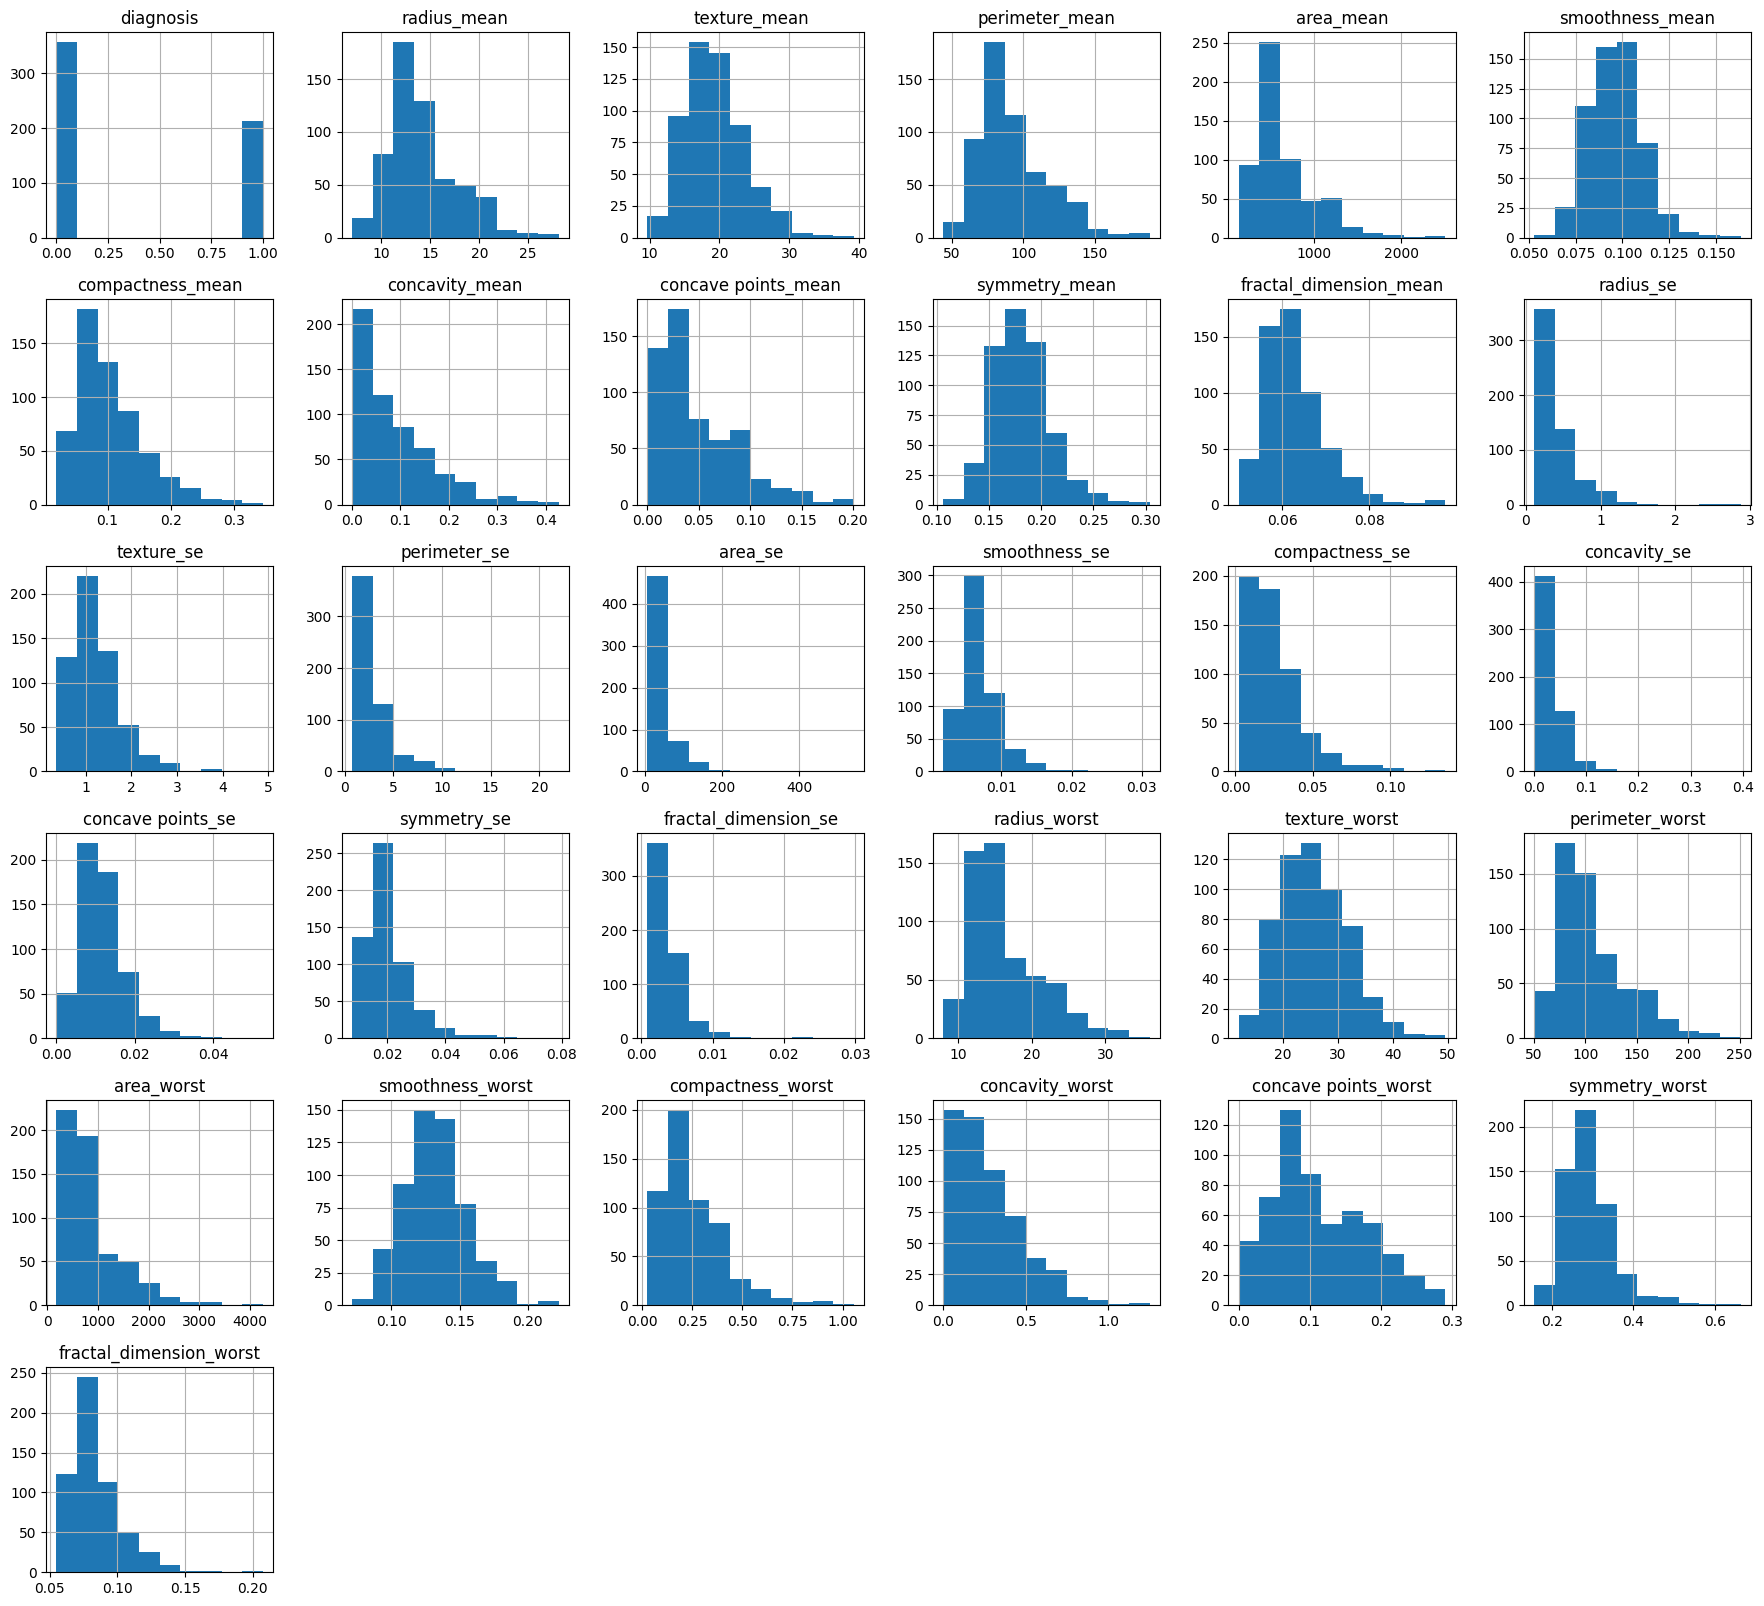

In [ ]:
cancer.hist(figsize=(22,20))
plt.show()

**Split data**

In [ ]:
X = cancer.drop('diagnosis', axis=1)
y = cancer['diagnosis']

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(X,y,test_size=0.20,random_state=1,stratify=y)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp,test_size=0.25,random_state=1,stratify=y_temp)

In [ ]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (341, 30)
Validation: (114, 30)
Testing: (114, 30)


**Scale values of input for KNN model**

In [ ]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train))
X_val_scaled = pd.DataFrame(scaler.transform(X_val))
X_test_scaled = pd.DataFrame(scaler.transform(X_test))

In [ ]:
X_train_scaled.describe()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
count,3.410000e+02,3.410000e+02,3.410000e+02,3.410000e+02,3.410000e+02,3.410000e+02,3.410000e+02,3.410000e+02,3.410000e+02,3.410000e+02,...,3.410000e+02,3.410000e+02,3.410000e+02,3.410000e+02,3.410000e+02,3.410000e+02,3.410000e+02,3.410000e+02,3.410000e+02,3.410000e+02
mean,-4.219499e-16,1.172083e-16,-1.041852e-17,-2.995323e-16,-1.157758e-15,1.080921e-16,-8.334812e-17,-1.510685e-16,-6.433433e-16,2.500444e-16,...,-3.906943e-18,-4.245545e-16,-2.370212e-16,-1.328361e-16,4.193452e-16,5.209258e-18,-1.119990e-16,6.772035e-17,-1.328361e-16,1.536731e-16
std,1.001470e+00,1.001470e+00,1.001470e+00,1.001470e+00,1.001470e+00,1.001470e+00,1.001470e+00,1.001470e+00,1.001470e+00,1.001470e+00,...,1.001470e+00,1.001470e+00,1.001470e+00,1.001470e+00,1.001470e+00,1.001470e+00,1.001470e+00,1.001470e+00,1.001470e+00,1.001470e+00
min,-1.970999e+00,-2.206198e+00,-1.920058e+00,-1.408987e+00,-3.109046e+00,-1.497677e+00,-1.097083e+00,-1.229900e+00,-2.467761e+00,-1.851167e+00,...,-1.656606e+00,-2.165044e+00,-1.619104e+00,-1.165576e+00,-2.692109e+00,-1.396113e+00,-1.277289e+00,-1.698003e+00,-2.139074e+00,-1.571548e+00
25%,-6.789924e-01,-7.845325e-01,-6.902011e-01,-6.596476e-01,-7.544501e-01,-7.402428e-01,-7.667978e-01,-7.417915e-01,-6.751513e-01,-6.910386e-01,...,-6.832781e-01,-7.572398e-01,-6.780064e-01,-6.356402e-01,-6.684239e-01,-7.218630e-01,-7.760273e-01,-7.705741e-01,-6.395681e-01,-6.666304e-01
50%,-2.344252e-01,-7.603818e-02,-2.355243e-01,-3.051745e-01,-6.092489e-02,-2.143120e-01,-3.443196e-01,-4.166338e-01,-7.000296e-02,-2.185553e-01,...,-2.757466e-01,-3.230162e-02,-2.954556e-01,-3.506589e-01,-6.611046e-02,-2.668296e-01,-2.351799e-01,-2.149391e-01,-1.270787e-01,-2.702305e-01
75%,5.249288e-01,6.464857e-01,4.890921e-01,3.762931e-01,6.177693e-01,4.524319e-01,5.519088e-01,6.927716e-01,5.351454e-01,4.560056e-01,...,4.918370e-01,7.347089e-01,4.942628e-01,3.276394e-01,5.977532e-01,4.957395e-01,5.128005e-01,7.306977e-01,4.629169e-01,4.247976e-01
max,3.672796e+00,3.429021e+00,3.777736e+00,5.069077e+00,4.713946e+00,4.307214e+00,4.095902e+00,3.514774e+00,4.150812e+00,5.009291e+00,...,3.904419e+00,3.521190e+00,4.062285e+00,5.564149e+00,3.965433e+00,4.758841e+00,4.108170e+00,2.574983e+00,5.885182e+00,6.529674e+00


**Train data on baseline Model (Logistic Regression)**

Logistic regression on non-scaled data

In [ ]:
lr=LogisticRegression()
lr.fit(X_train,y_train)
y_train_pred = lr.predict(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.9560117302052786


In [ ]:
y_val_pred = lr.predict(X_val)
val_accracy=accuracy_score(y_val,y_val_pred)
print("Validation Accuracy", val_accracy)

Validation Accuracy 0.8947368421052632


In [ ]:
y_test_pred = lr.predict(X_test)
val_accracy=accuracy_score(y_test,y_test_pred)
print("Testing Accuracy", val_accracy)

Testing Accuracy 0.956140350877193


**LogisticRegression on scaled data**

In [ ]:
lr=LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled,y_train)
y_train_pred = lr.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", train_accuracy)
y_val_pred = lr.predict(X_val_scaled)
val_accracy=accuracy_score(y_val,y_val_pred)
print("Validation Accuracy", val_accracy)
y_test_pred = lr.predict(X_test_scaled)
val_accracy=accuracy_score(y_test,y_test_pred)
print("Testing Accuracy", val_accracy)

Training Accuracy: 0.9912023460410557
Validation Accuracy 0.9736842105263158
Testing Accuracy 0.9824561403508771


**Analyze model by different params**

In [ ]:
cm=confusion_matrix(y_test,y_test_pred)
print(cm)


[[71  1]
 [ 1 41]]


In [ ]:
report=classification_report(y_test,y_test_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        72
           1       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**check cross val score too**

In [ ]:
score=cross_val_score(lr,X,y,cv=5)
print(score)


[0.93859649 0.94736842 0.98245614 0.92982456 0.95575221]


In [79]:
score_lr=sum(score)/len(score)
print(score_lr)

0.9507995652848935


**Train Data using Decision Tree**

In [ ]:
model2=DecisionTree(max_depth=5,min_samples_split=10,min_samples_leaf=5,random_state=1)
model2.fit(X_train, y_train)
y_train_pred = model2.predict(X_train)
train_accuracy=accuracy_score(y_train,y_train_pred)
print("Training Accuracy:",train_accuracy)
y_val_pred=model2.predict(X_val)
val_accracy=accuracy_score(y_val,y_val_pred)
print("Validation Accuracy: ", val_accracy )
y_test_pred=model2.predict(X_test)
testing_accuracy=accuracy_score(y_test,y_test_pred)
print("Testing Accuracy: ", testing_accuracy)


Training Accuracy: 0.9794721407624634
Validation Accuracy:  0.9122807017543859
Testing Accuracy:  0.8947368421052632


**Cross_val** of decision tree

In [ ]:
score2=cross_val_score(model2,X,y,cv=5)
print(score2)
score_dt=sum(score2)/len(score2)
print(score_dt)

[0.92105263 0.89473684 0.95614035 0.94736842 0.9380531 ]
0.9314702685918336


**Train using Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model3=RandomForestClassifier(n_estimators=200, max_depth=6,min_samples_leaf=3,random_state=1)
model3.fit(X_train,y_train)
y_train_pred=model3.predict(X_train)
train_accuracy=accuracy_score(y_train,y_train_pred)
print("Training Accuracy:",train_accuracy)
y_val_pred=model3.predict(X_val)
val_accracy=accuracy_score(y_val,y_val_pred)
print("Validation Accuracy: ", val_accracy )
y_test_pred=model3.predict(X_test)
testing_accuracy=accuracy_score(y_test,y_test_pred)
print("Testing Accuracy: ", testing_accuracy)

Training Accuracy: 0.9882697947214076
Validation Accuracy:  0.9122807017543859
Testing Accuracy:  0.956140350877193


**CrossVal of Random Forest**

In [80]:
score3=cross_val_score(model3,X,y,cv=5)
print(score3)
score_rf=sum(score3)/len(score3)
print(score_rf)

[0.92105263 0.93859649 0.98245614 0.97368421 0.96460177]
0.956078248719143


**ROC curve**

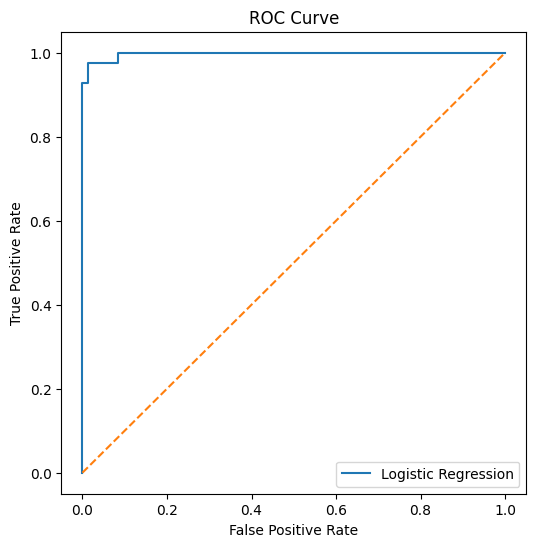

In [89]:
from sklearn.metrics import roc_curve
y_prob = lr.predict_proba(X_test_scaled)[: ,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [84]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 0.9973544973544973


**Comparison Table**

| Model               | Train | Validation | Test  | CV Score | Overfitting |
| ------------------- | ----- | ---------- | ----- | -------- | ----------- |
| Logistic Regression | 99.1% | 97.3%      | 98.2% | 95.1%    | No          |
| Decision Tree       | 97.9% | 91.2%      | 89.5% | 93.1%    | Slight      |
| Random Forest       | 98.8% | 91.2%      | 95.6% | 95.8%    | Slight      |


Logistic Regression achieved the highest testing accuracy and ROC-AUC score with minimal overfitting, making it the preferred model for this dataset.

In [90]:
import joblib

joblib.dump(lr, "breast_cancer_model.pkl")

['breast_cancer_model.pkl']